# XGBoost — Pipeline de Détection d'Intrusion Réseau (IDS) · Multiclasse

**Tâche** : Classification multiclasse — 15 classes (BENIGN + 14 types d'attaques)  
**Données** : Pré-nettoyées et pré-splittées (chargées depuis `ml_ready/`)

---

### Principes appliqués dans ce notebook

| Principe | Implémentation |
|---|---|
| **Zéro data-leak** | `X_test` / `dtest` touchés **uniquement** à la cellule §14 |
| **Anti-overfitting** | Early stopping · régularisation L1/L2 · `min_child_weight` · CV 5-fold |
| **Crash-resilient** | Study Optuna persisté en SQLite — reprend après redémarrage kernel |
| **Reproductible** | `RANDOM_STATE = 42` partout · seeds fixes |
| **Portable** | Paths configurables : switch Local ↔ Google Colab en 3 lignes |
| **Multiclasse robuste** | `multi:softprob` · `num_class` dynamique · macro-F1 comme métrique pilote |


## §1 · Dépendances

In [18]:
# Installer les paquets nécessaires.
# - xgboost>=2.0        : API 'hist' + multi:softprob
# - optuna>=3.0         : TPE sampler + HyperbandPruner
# - optuna-integration  : XGBoostPruningCallback
# - imbalanced-learn    : SMOTE sur training set uniquement
# - shap                : explainabilité SHAP TreeExplainer (multiclasse)
# - mlflow              : tracking des expériences
!pip install -q "xgboost>=2.0" "optuna>=3.0" "optuna-integration[xgboost]" \
    imbalanced-learn shap mlflow scikit-learn

KeyboardInterrupt: 

## §2 · Imports

In [ ]:
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import xgboost as xgb
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
from optuna.storages import RDBStorage
from optuna_integration import XGBoostPruningCallback  # optuna >= 3.0

import shap
import mlflow
import mlflow.xgboost

# ── Silencer les warnings non-critiques ──────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.basicConfig(level=logging.INFO, format="%(levelname)s │ %(message)s")
log = logging.getLogger(__name__)

# ── Style des graphiques ──────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"         : 130,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
})
sns.set_theme(style="whitegrid", palette="muted")

log.info("XGBoost %s | Optuna %s | Imports OK", xgb.__version__, optuna.__version__)

## §3 · Configuration

> **Seule section à modifier** selon votre environnement.

In [ ]:
# ── Option A : Google Colab ───────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
ML_READY   = "/content/drive/MyDrive/PFA_/Preprocessed-attacks/"
OUTPUT_DIR = Path("/content/drive/MyDrive/PFA_/outputs-XGboost-attacks")

# ── Option B : Environnement local ───────────────────────────────────────────
#ML_READY   = "data/ml_ready/"
#OUTPUT_DIR = Path("outputs")

# Fichiers attendus dans ML_READY/ :
#   X_train_final.csv   features d'entraînement
#   X_test_final.csv    features de test (NE PAS TOUCHER avant §14)
#   y_train_final.csv   labels train : strings (ex: "BENIGN", "DDoS", ...)
#   y_test_final.csv    labels test  : même convention

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OPTUNA_DB  = OUTPUT_DIR / "optuna_study_mc.db"
OPTUNA_URL = f"sqlite:///{OPTUNA_DB}"

# ── Hyperparamètres globaux ───────────────────────────────────────────────────
EXPERIMENT_NAME   = "xgboost_ids_multiclass"
RANDOM_STATE      = 42
N_SPLITS          = 5
VAL_SIZE          = 0.15
N_OPTUNA_TRIALS   = 60
EARLY_STOP_ROUNDS = 50
SHAP_SAMPLE_SIZE  = 1500   # réduit car multiclasse = N_CLASSES fois plus de valeurs SHAP

# ── Seuil de déséquilibre pour déclenchement SMOTE ───────────────────────────
SMOTE_RATIO_THRESHOLD = 50   # si max_class / min_class > 50 : SMOTE activé

np.random.seed(RANDOM_STATE)
log.info("Config OK | ML_READY=%s | OUTPUT_DIR=%s", ML_READY, OUTPUT_DIR.resolve())

## §4 · Chargement des données

> Les données sont déjà nettoyées et splittées. Ce notebook ne fait aucune transformation sur les features.

**Note multiclasse** : Les labels sont des chaînes (ex: `"BENIGN"`, `"DDoS"`, `"Bot"`).  
Un `LabelEncoder` est fitté **uniquement sur `y_train`** pour convertir en entiers 0…N-1.  
La même transformation est appliquée à `y_test` — aucune information du test set n'est utilisée pour ce fit.

In [ ]:
X_train = pd.read_csv(ML_READY + "X_train.csv")
X_test  = pd.read_csv(ML_READY + "X_test.csv")
y_train_raw = pd.read_csv(ML_READY + "y_train.csv").squeeze()
y_test_raw  = pd.read_csv(ML_READY + "y_test.csv").squeeze()

FEATURE_NAMES = X_train.columns.tolist()

# ── LabelEncoder fitté UNIQUEMENT sur y_train ─────────────────────────────────
# Importance : ne JAMAIS appeler fit() sur y_test — ce serait une fuite.
le = LabelEncoder()
y_train = pd.Series(le.fit_transform(y_train_raw), name="label")
y_test  = pd.Series(le.transform(y_test_raw),      name="label")  # transform seulement

CLASS_NAMES = list(le.classes_)           # noms dans l'ordre des entiers
N_CLASSES   = len(CLASS_NAMES)

print(f"Classes détectées ({N_CLASSES}) : {CLASS_NAMES}")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}  ← isolé jusqu'à §14")
print(f"Features: {len(FEATURE_NAMES)}")
print()
print("Distribution y_train :")
vc = y_train.value_counts().sort_index()
for i, cnt in vc.items():
    print(f"  [{i:2d}] {CLASS_NAMES[i]:<30} {cnt:>8,}  ({cnt/len(y_train):.2%})")

## §5 · Audit rapide

Vérifications de cohérence **avant tout entraînement**.

In [ ]:
assert list(X_train.columns) == list(X_test.columns), \
    "ERREUR : X_train et X_test n'ont pas les mêmes colonnes."
assert X_train.isnull().sum().sum() == 0, \
    f"ERREUR : {X_train.isnull().sum().sum()} NaN dans X_train."
assert X_test.isnull().sum().sum() == 0, \
    f"ERREUR : {X_test.isnull().sum().sum()} NaN dans X_test."
assert set(y_train.unique()) == set(range(N_CLASSES)), \
    f"Labels y_train inattendus : {sorted(y_train.unique())}"
# Les labels test doivent être un sous-ensemble de ceux de train
unseen = set(y_test.unique()) - set(y_train.unique())
assert len(unseen) == 0, f"Classes dans y_test absentes de y_train : {unseen}"

print("=" * 58)
for split_name, X, y in [("Train", X_train, y_train), ("Test ", X_test, y_test)]:
    vc = y.value_counts()
    ratio = vc.max() / vc.min()
    print(f"[{split_name}]  lignes={len(X):>7,}  features={X.shape[1]}"
          f"  dupes={X.duplicated().sum()}  ratio={ratio:.1f}x")
print("=" * 58)
print("✓ Toutes les assertions passées")

# ── Distribution des classes ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (split_name, y_split) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    vc = y_split.value_counts().sort_index()
    labels = [CLASS_NAMES[i] for i in vc.index]
    bars = ax.barh(labels, vc.values)
    ax.bar_label(bars, labels=[f"{v:,}" for v in vc.values], padding=3, fontsize=7)
    ax.set_title(f"{split_name} — distribution des classes")
    ax.set_xlabel("Nombre d'échantillons")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

## echantillon de 100 / 25

In [ ]:
from sklearn.model_selection import train_test_split

# ============================================================
# DEBUG SAMPLE (rapide pour tests pipeline)
# ============================================================

X_train_debug, _, y_train_debug, _ = train_test_split(
    X_train,
    y_train,
    train_size=100,
    stratify=y_train,
    random_state=42
)

X_test_debug, _, y_test_debug, _ = train_test_split(
    X_test,
    y_test,
    train_size=25,
    stratify=y_test,
    random_state=42
)

print("DEBUG SETS CREATED")
print("Train debug:", X_train_debug.shape)
print("Test debug :", X_test_debug.shape)

## §6 · Gestion du déséquilibre de classes (multiclasse)

### Pourquoi `scale_pos_weight` ne fonctionne PAS en multiclasse

`scale_pos_weight` est un paramètre **binaire uniquement**.  
En multiclasse (`multi:softprob`), XGBoost n'a pas d'équivalent direct.

### Stratégie adoptée : `sample_weight` + SMOTE sélectif

Deux mécanismes complémentaires sont utilisés, **uniquement sur X_train** :

1. **`sample_weight`** (toujours actif) : chaque exemple reçoit un poids inversement  
   proportionnel à la fréquence de sa classe. Cela pénalise davantage les erreurs  
   sur les classes rares sans modifier la distribution des données.

2. **SMOTE sélectif** (activé si le ratio dépasse `SMOTE_RATIO_THRESHOLD`) :  
   génère des exemples synthétiques pour les classes très minoritaires.  
   Appliqué **uniquement sur X_train** — `X_test` n'est jamais touché.

### Risque de leakage à éviter
Le fit SMOTE sur X_test constituerait une fuite de données. Ici, SMOTE est appliqué  
après le split train/test, sur les données d'entraînement seulement.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# ============================================================
# Gestion du déséquilibre (version optimisée IDS)
# ============================================================

vc_train = y_train.value_counts().sort_index()
imbalance_ratio = vc_train.max() / vc_train.min()

print(f"Ratio max/min classes : {imbalance_ratio:.1f}x")

# Sample weights (solution principale recommandée)
SAMPLE_WEIGHT_TRAIN = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# On garde les données originales (PAS de SMOTE)
X_train_bal = X_train.copy()
y_train_bal = y_train.copy()

SMOTE_APPLIED = False
SAMPLE_WEIGHT_TRAIN_BAL = SAMPLE_WEIGHT_TRAIN

print("\n✓ SMOTE désactivé volontairement")
print("✓ Utilisation de class/sample weights (recommandé pour RF & XGBoost)")

print(f"\nSample weights : min={SAMPLE_WEIGHT_TRAIN.min():.4f} | "
      f"max={SAMPLE_WEIGHT_TRAIN.max():.4f}")

In [ ]:
#from sklearn.utils.class_weight import compute_sample_weight

#vc_train = y_train.value_counts().sort_index()
#imbalance_ratio = vc_train.max() / vc_train.min()

#print(f"Ratio max/min classes : {imbalance_ratio:.1f}x")
#print(f"Seuil SMOTE           : {SMOTE_RATIO_THRESHOLD}x")

# ── Sample weights (toujours calculés) ───────────────────────────────────────
#SAMPLE_WEIGHT_TRAIN = compute_sample_weight("balanced", y_train)

#X_train_bal = X_train.copy()
#y_train_bal = y_train.copy()
#SMOTE_APPLIED = False

#if imbalance_ratio > SMOTE_RATIO_THRESHOLD:
    #print("\n⚠ Déséquilibre sévère — application de SMOTETomek sur X_train uniquement")
    # SMOTETomek = SMOTE (sur-échantillonnage) + Tomek Links (sous-échantillonnage frontière)
    # Seulement sur les classes avec moins de 6 exemples, k_neighbors est réduit
    #min_count = vc_train.min()
    #k = min(5, min_count - 1)
    #smote = SMOTETomek(
        #smote=SMOTE(k_neighbors=k, random_state=RANDOM_STATE),
        #random_state=RANDOM_STATE
    #)
    #X_bal_np, y_bal_np = smote.fit_resample(X_train.values, y_train.values)
    #X_train_bal = pd.DataFrame(X_bal_np, columns=FEATURE_NAMES)
    #y_train_bal = pd.Series(y_bal_np, name="label")
    #SAMPLE_WEIGHT_TRAIN_BAL = compute_sample_weight("balanced", y_train_bal)
    #SMOTE_APPLIED = True
    #print(f"  Avant SMOTE : {len(X_train):,} exemples")
    #print(f"  Après SMOTE : {len(X_train_bal):,} exemples")
#else:
    #print("\n✓ Déséquilibre modéré — sample_weight suffit, SMOTE non activé")
    #SAMPLE_WEIGHT_TRAIN_BAL = SAMPLE_WEIGHT_TRAIN

#print(f"\nSample weights : min={SAMPLE_WEIGHT_TRAIN_BAL.min():.4f} | "
      #f"max={SAMPLE_WEIGHT_TRAIN_BAL.max():.4f}")

## §7 · DMatrix et isolation du test set

```
X_train_bal (données rééquilibrées)
  ├── X_tr_opt (85%)  →  dtrain_opt  ← §9 Baseline + §10 Optuna
  └── X_val    (15%)  →  dval        ← early stopping uniquement

X_train_bal (100%)    →  dtrain      ← §12 xgb.cv + entraînement final
X_test  (100%)        →  dtest       ← §14 UNIQUEMENT — jamais avant
```

> **Règle** : `dtest` n'apparaît dans aucun `evals=` ni aucun calcul avant §14.

In [ ]:
from sklearn.model_selection import train_test_split

# ── Val set extrait de X_train_bal uniquement ─────────────────────────────────
X_tr_opt, X_val, y_tr_opt, y_val = train_test_split(
    X_train_bal, y_train_bal,
    test_size    = VAL_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y_train_bal,
)

# Sample weights pour la portion opt (alignés par index)
sw_tr_opt = compute_sample_weight("balanced", y_tr_opt)

# ── DMatrix XGBoost (avec sample_weight pour déséquilibre) ───────────────────
dtrain     = xgb.DMatrix(X_train_bal, label=y_train_bal,
                          weight=SAMPLE_WEIGHT_TRAIN_BAL,
                          feature_names=FEATURE_NAMES)
dtrain_opt = xgb.DMatrix(X_tr_opt, label=y_tr_opt,
                          weight=sw_tr_opt,
                          feature_names=FEATURE_NAMES)
dval       = xgb.DMatrix(X_val,    label=y_val,
                          feature_names=FEATURE_NAMES)
dtest      = xgb.DMatrix(X_test,   label=y_test,
                          feature_names=FEATURE_NAMES)  # TEST ISOLÉ

log.info("DMatrix OK — full-train=%d | opt-train=%d | val=%d | test=%d | features=%d | classes=%d",
         dtrain.num_row(), dtrain_opt.num_row(),
         dval.num_row(), dtest.num_row(), len(FEATURE_NAMES), N_CLASSES)

## §8 · Objectif XGBoost multiclasse

### `multi:softprob` vs `multi:softmax`

| | `multi:softmax` | `multi:softprob` |
|---|---|---|
| **Sortie** | entier (classe prédite) | vecteur de probabilités [N_CLASSES] |
| **early stopping** | ✓ | ✓ |
| **SHAP multiclasse** | ✗ (pas de proba) | ✓ |
| **Calibration** | impossible | possible |

`multi:softprob` est préférable pour l'explicabilité et l'analyse des classes rares.

### Métrique pilote : `mlogloss`

Le *multiclass log-loss* pénalise proportionnellement à la confiance mal placée.  
C'est la métrique naturelle pour `multi:softprob`.

In [ ]:
OBJECTIVE      = "multi:softprob"
EVAL_METRIC    = ["mlogloss", "merror"]   # [0] = métrique early stopping
PRIMARY_METRIC = "mlogloss"               # val-mlogloss minimisé par Optuna

log.info("objective=%s | eval_metric=%s | num_class=%d",
         OBJECTIVE, EVAL_METRIC, N_CLASSES)

## §9 · Modèle de base

Entraîné avec des hyperparamètres raisonnables et fixes.  
Sert de **point de référence** avant Optuna et valide le pipeline end-to-end.

In [ ]:
BASELINE_PARAMS = {
    "objective": OBJECTIVE,
    "eval_metric": EVAL_METRIC,
    "num_class": N_CLASSES,

    "tree_method": "hist",

    "learning_rate": 0.05,
    "max_depth": 5,

    "subsample": 0.8,
    "colsample_bytree": 0.8,

    "min_child_weight": 5,

    "reg_alpha": 0.1,
    "reg_lambda": 1.0,

    "seed": RANDOM_STATE,
    "verbosity": 0,
}

evals_result_baseline = {}
baseline_model = xgb.train(
    params                = BASELINE_PARAMS,
    dtrain                = dtrain_opt,
    num_boost_round       = 400,
    evals                 = [(dtrain_opt, "train"), (dval, "val")],
    early_stopping_rounds = 50,
    evals_result          = evals_result_baseline,
    verbose_eval          = False,
)

best_baseline_iter  = baseline_model.best_iteration
best_baseline_loss  = evals_result_baseline["val"]["mlogloss"][best_baseline_iter]
best_baseline_err   = evals_result_baseline["val"]["merror"][best_baseline_iter]
log.info("Baseline — best iter: %d | val-mlogloss: %.4f | val-merror: %.4f",
         best_baseline_iter, best_baseline_loss, best_baseline_err)

# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["mlogloss", "merror"]):
    ax.plot(evals_result_baseline["train"][metric], label="Train", linewidth=1.4)
    ax.plot(evals_result_baseline["val"][metric],   label="Val",   linewidth=1.4)
    ax.axvline(best_baseline_iter, color="grey", linestyle="--", linewidth=1,
               label=f"Best iter ({best_baseline_iter})")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel(metric)
    ax.set_title(f"Baseline — {metric}")
    ax.legend()
plt.suptitle("Courbes d'apprentissage — Baseline", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_learning_curves.png", bbox_inches="tight")
plt.show()

# ── Évaluation rapide baseline sur val set ────────────────────────────────────
y_prob_val_raw = baseline_model.predict(dval)                      # (n, N_CLASSES)
y_pred_val     = np.argmax(y_prob_val_raw.reshape(-1, N_CLASSES), axis=1)
f1_baseline    = f1_score(y_val, y_pred_val, average="macro", zero_division=0)
print(f"Baseline val macro-F1 : {f1_baseline:.4f}")

## §10 · Optimisation des hyperparamètres (Optuna)

### Pourquoi macro-F1 comme métrique d'optimisation ?

Sur CIC-IDS2017, les classes d'attaques rares (ex: Infiltration, Heartbleed) ont  
quelques centaines d'exemples contre des centaines de milliers de BENIGN.  
L'accuracy et le mlogloss sont dominés par les classes majoritaires — un modèle  
qui ignore les classes rares obtient encore 98% d'accuracy.

Le **macro-F1 traite chaque classe avec le même poids**, forçant le modèle à performer  
sur les classes rares. C'est la métrique standard pour l'évaluation IDS multiclasse.

**Algorithme** : TPE (Tree-structured Parzen Estimator)  
**Pruner** : Hyperband — coupe les trials peu prometteurs  
**Persistance** : SQLite — reprend après crash kernel

## Recuperation Optuna Results

In [ ]:
db_path = "/content/drive/MyDrive/PFA_/outputs-XGboost-attacks/optuna_study_mc.db"
from optuna.storages import RDBStorage
import optuna

OPTUNA_URL = f"sqlite:///{db_path}"

storage = RDBStorage(
    url=OPTUNA_URL,
    engine_kwargs={"connect_args": {"timeout": 30}},
)

study = optuna.load_study(
    study_name=EXPERIMENT_NAME,
    storage=storage,
)

print("Best trial :", study.best_trial.number)
print("Best macro-F1 :", study.best_value)
print("Best params :")
print(study.best_params)

## Optuna Calcul (Original)

In [ ]:
# DO NOT RUN !
storage = RDBStorage(
    url           = OPTUNA_URL,
    engine_kwargs = {"connect_args": {"timeout": 30}},
)
study = optuna.create_study(
    study_name=EXPERIMENT_NAME,
    storage=storage,
    direction="maximize",

    sampler=TPESampler(
        seed=RANDOM_STATE,
        n_startup_trials=10,
    ),

    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=20,
    ),

    load_if_exists=True,
)

n_done      = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_remaining = max(0, N_OPTUNA_TRIALS - n_done)
log.info("Study '%s' — %d/%d trials | %d restants",
         EXPERIMENT_NAME, n_done, N_OPTUNA_TRIALS, n_remaining)


def optuna_objective(trial: optuna.Trial) -> float:
    """
    Objectif Optuna multiclasse.
    Optimise le macro-F1 tout en utilisant le mlogloss
    pour l'early stopping et le pruning.
    """

    params = {
        "objective": OBJECTIVE,
        "eval_metric": EVAL_METRIC,
        "num_class": N_CLASSES,

        "tree_method": "hist",   # remplacer par "gpu_hist" si GPU disponible

        "seed": RANDOM_STATE,
        "verbosity": 0,

        # Hyperparamètres à optimiser
        "learning_rate": trial.suggest_float(
            "learning_rate", 1e-3, 0.2, log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 20
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 0.0, 3.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 5.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 5.0, log=True
        ),
    }

    evals_res = {}

    model = xgb.train(
        params=params,
        dtrain=dtrain_opt,

        # réduit fortement le temps
        num_boost_round=400,

        evals=[(dval, "val")],

        early_stopping_rounds=30,

        evals_result=evals_res,

        callbacks=[
            XGBoostPruningCallback(
                trial,
                f"val-{PRIMARY_METRIC}"
            )
        ],

        verbose_eval=False,
    )

    # Prédictions validation
    y_prob = model.predict(dval)
    y_pred = np.argmax(y_prob, axis=1)

    macro_f1 = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    trial.set_user_attr(
        "best_mlogloss",
        evals_res["val"]["mlogloss"][model.best_iteration]
    )

    trial.set_user_attr(
        "best_round",
        model.best_iteration
    )

    return macro_f1


if n_remaining > 0:
    log.info("Lancement de %d trials...", n_remaining)
    study.optimize(
        optuna_objective,
        n_trials          = n_remaining,
        show_progress_bar = True,
        gc_after_trial    = True,
    )
else:
    log.info("Tous les %d trials déjà complétés.", N_OPTUNA_TRIALS)

best_trial = study.best_trial
log.info("Meilleur trial #%d — macro-F1=%.4f | mlogloss=%.6f",
         best_trial.number,
         study.best_value,
         best_trial.user_attrs.get("best_mlogloss", float("nan")))

In [33]:
# affichage

print("Best trial :", study.best_trial.number)
print("Best macro-F1 :", study.best_value)
print("Best params :")
print(study.best_params)

Best trial : 58
Best macro-F1 : 0.9316708974201349
Best params :
{'learning_rate': 0.04978469532771608, 'max_depth': 3, 'min_child_weight': 13, 'subsample': 0.8548782352207237, 'colsample_bytree': 0.6672146298870487, 'gamma': 2.5388714990780334, 'reg_alpha': 0.0023324846235665605, 'reg_lambda': 0.00011915817124656364}


## §11 · Résultats Optuna

<Figure size 910x520 with 0 Axes>

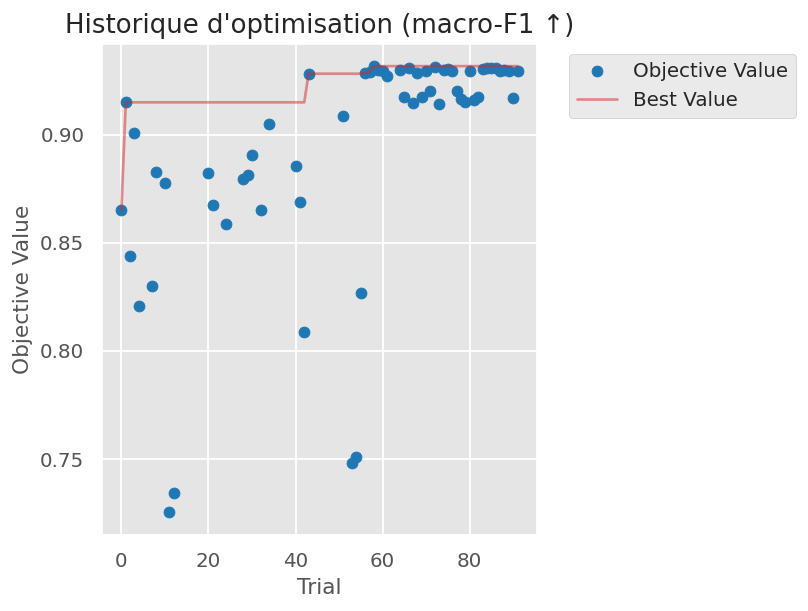

<Figure size 910x520 with 0 Axes>

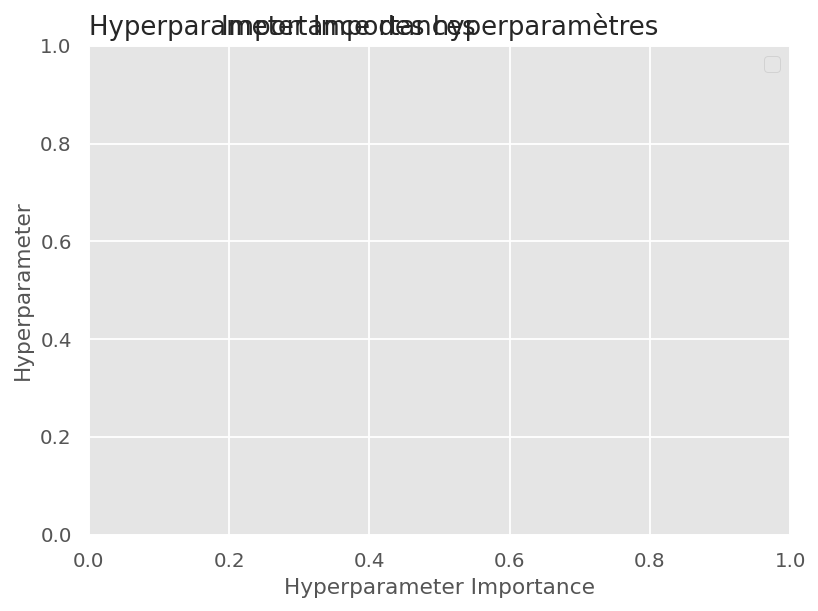

Top 5 trials (macro-F1 ↑) :


,number,value,state,user_attrs_best_mlogloss,user_attrs_best_round
58,58,0.931671,COMPLETE,0.007560,281.0
72,72,0.931174,COMPLETE,0.007046,204.0
85,85,0.930933,COMPLETE,0.013784,185.0
86,86,0.930883,COMPLETE,0.006313,338.0
66,66,0.930646,COMPLETE,0.006982,119.0



Meilleurs hyperparamètres : {'learning_rate': 0.04978469532771608, 'max_depth': 3, 'min_child_weight': 13, 'subsample': 0.8548782352207237, 'colsample_bytree': 0.6672146298870487, 'gamma': 2.5388714990780334, 'reg_alpha': 0.0023324846235665605, 'reg_lambda': 0.00011915817124656364}


In [32]:
# ── Historique d'optimisation ─────────────────────────────
plt.figure(figsize=(7,4))
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Historique d'optimisation (macro-F1 ↑)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", bbox_inches="tight")
plt.show()

# ── Importance des hyperparamètres ───────────────────────
plt.figure(figsize=(7,4))
optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Importance des hyperparamètres")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_param_importance.png", bbox_inches="tight")
plt.show()

# ── Tableau des trials ───────────────────────────────────
trials_df = study.trials_dataframe(
    attrs=("number", "value", "state", "user_attrs")
)

trials_df = (
    trials_df[trials_df["state"] == "COMPLETE"]
    .sort_values("value", ascending=False)
)

print("Top 5 trials (macro-F1 ↑) :")
display(trials_df.head(5))

print(f"\nMeilleurs hyperparamètres : {study.best_params}")

## §12 · Entraînement du modèle final

**Étape 1** — `xgb.cv` détermine le nombre optimal d'arbres sur `X_train_bal` complet.  
**Étape 2** — Le modèle final est entraîné sur `X_train_bal` complet avec ce nombre d'arbres.  

`X_test` n'est **jamais** utilisé dans ces étapes.

In [ ]:
FINAL_PARAMS = {
    "objective": OBJECTIVE,
    "eval_metric": "mlogloss",
    "num_class": N_CLASSES,

    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 0,

    **study.best_params,
}

# ── CV pour choisir le nombre d'arbres ─────────────────────────────
cv_xgb = xgb.cv(
    params=FINAL_PARAMS,
    dtrain=dtrain,

    num_boost_round=800,
    nfold=N_SPLITS,
    stratified=True,

    early_stopping_rounds=50,

    seed=RANDOM_STATE,
    verbose_eval=False,
)

# ✔ méthode propre
best_n_rounds = len(cv_xgb)

cv_mlogloss = cv_xgb["test-mlogloss-mean"]

print(f"xgb.cv — best rounds : {best_n_rounds}")
print(f"best CV mlogloss : {cv_mlogloss.min():.6f}")

# ── Courbe CV ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(cv_xgb["train-mlogloss-mean"], label="Train")
ax.plot(cv_xgb["test-mlogloss-mean"], label="CV")
ax.axvline(best_n_rounds - 1, color="red", linestyle="--")
ax.set_title("CV - mlogloss")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_learning_curve.png")
plt.show()

# ── Modèle final ─────────────────────────────
final_model = xgb.train(
    params=FINAL_PARAMS,
    dtrain=dtrain,
    num_boost_round=best_n_rounds,
    verbose_eval=False,
)

model_path = OUTPUT_DIR / "xgboost_multiclass_final.ubj"
final_model.save_model(str(model_path))

log.info("Model saved: %s", model_path)

xgb.cv — best rounds : 185
best CV mlogloss : 0.188652


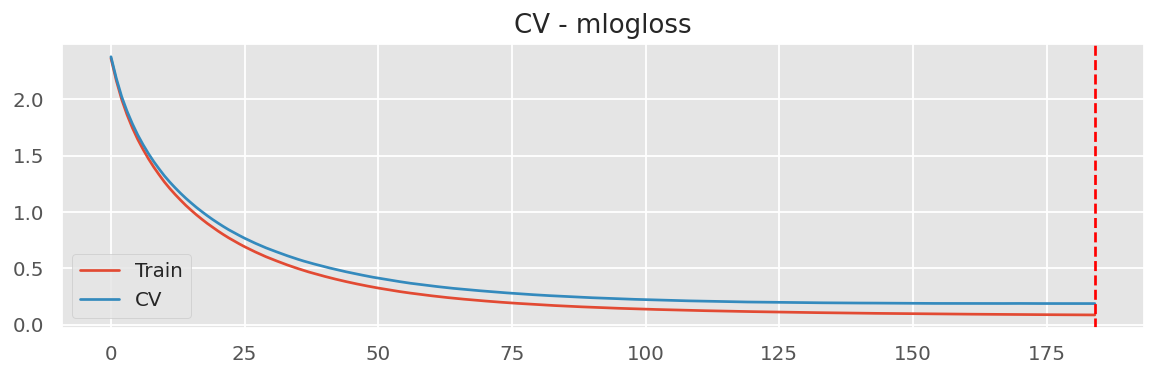

In [31]:
# affichage
print(f"xgb.cv — best rounds : {best_n_rounds}")
print(f"best CV mlogloss : {cv_mlogloss.min():.6f}")

# ── Courbe CV ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(cv_xgb["train-mlogloss-mean"], label="Train")
ax.plot(cv_xgb["test-mlogloss-mean"], label="CV")
ax.axvline(best_n_rounds - 1, color="red", linestyle="--")
ax.set_title("CV - mlogloss")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_learning_curve.png")
plt.show()

## §13 · Validation croisée — métriques multiclasses

Estimation de la généralisation du modèle final via `StratifiedKFold` sur `X_train_bal`.  
Aucune donnée de `X_test` n'est impliquée.

In [20]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_f1_macro = []
cv_f1_weighted = []
cv_bal_acc = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_bal, y_train_bal)):

    Xf_tr = X_train_bal.iloc[train_idx]
    Xf_val = X_train_bal.iloc[val_idx]

    yf_tr = y_train_bal.iloc[train_idx]
    yf_val = y_train_bal.iloc[val_idx]

    dval_fold = xgb.DMatrix(Xf_val)

    fold_model = xgb.train(
        params=FINAL_PARAMS,
        dtrain=dtrain_fold,
        num_boost_round=best_n_rounds,
        verbose_eval=False,
    )

    y_prob = fold_model.predict(dval_fold)
    y_pred = np.argmax(y_prob, axis=1)

    cv_f1_macro.append(
        f1_score(yf_val, y_pred, average="macro", zero_division=0)
    )

    cv_f1_weighted.append(
        f1_score(yf_val, y_pred, average="weighted", zero_division=0)
    )

    cv_bal_acc.append(
        balanced_accuracy_score(yf_val, y_pred)
    )

    print(
        f"Fold {fold_idx+1}/{N_SPLITS} — "
        f"macro-F1: {cv_f1_macro[-1]:.4f} | "
        f"weighted-F1: {cv_f1_weighted[-1]:.4f} | "
        f"bal-acc: {cv_bal_acc[-1]:.4f}"
    )

cv_f1_macro = np.array(cv_f1_macro)
cv_f1_weighted = np.array(cv_f1_weighted)
cv_bal_acc = np.array(cv_bal_acc)

print("\n" + "="*50)
print(f"macro-F1    : {cv_f1_macro.mean():.4f} ± {cv_f1_macro.std():.4f}")
print(f"weighted-F1 : {cv_f1_weighted.mean():.4f} ± {cv_f1_weighted.std():.4f}")
print(f"bal-acc     : {cv_bal_acc.mean():.4f} ± {cv_bal_acc.std():.4f}")
print("="*50)

Fold 1/5 — macro-F1: 0.9256 | weighted-F1: 0.9978 | bal-acc: 0.9641
Fold 2/5 — macro-F1: 0.9308 | weighted-F1: 0.9976 | bal-acc: 0.9607
Fold 3/5 — macro-F1: 0.9517 | weighted-F1: 0.9981 | bal-acc: 0.9635
Fold 4/5 — macro-F1: 0.9228 | weighted-F1: 0.9976 | bal-acc: 0.9556
Fold 5/5 — macro-F1: 0.9003 | weighted-F1: 0.9974 | bal-acc: 0.9425

macro-F1    : 0.9262 ± 0.0165
weighted-F1 : 0.9977 ± 0.0003
bal-acc     : 0.9573 ± 0.0080


## §14 · Évaluation finale sur le test set

> **Premier et unique contact avec X_test.**  
> Toutes les décisions de modélisation ont été prises avant cette cellule.

### Métriques primaires (déséquilibre multiclasse)
- **Macro-F1** : traite toutes les classes également — critique pour les attaques rares
- **Weighted-F1** : pondéré par le support — reflète la performance globale
- **Balanced Accuracy** : moyenne des recalls par classe

### Métrique secondaire
- **Accuracy** : utile pour le reporting mais trompeuse sur données déséquilibrées

In [21]:
# ── Prédictions ──────────────────────────────────────────────────────────────
y_prob_raw  = final_model.predict(dtest)                        # (n * N_CLASSES,) flattened
y_prob      = y_prob_raw.reshape(-1, N_CLASSES)                 # (n, N_CLASSES)
y_pred      = np.argmax(y_prob, axis=1)                        # classe prédite

# ── Métriques ─────────────────────────────────────────────────────────────────
acc      = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro",    zero_division=0)
f1_w     = f1_score(y_test, y_pred, average="weighted", zero_division=0)
bal_acc  = balanced_accuracy_score(y_test, y_pred)

metrics = {
    "macro_f1"          : f1_macro,
    "weighted_f1"       : f1_w,
    "balanced_accuracy" : bal_acc,
    "accuracy"          : acc,           # secondaire
}

print("\n" + "═" * 55)
print("  TEST SET METRICS (15 classes)")
print("═" * 55)
print(f"  {'macro_f1':<28} {f1_macro:.4f}  ← métrique primaire")
print(f"  {'weighted_f1':<28} {f1_w:.4f}")
print(f"  {'balanced_accuracy':<28} {bal_acc:.4f}")
print(f"  {'accuracy (secondaire)':<28} {acc:.4f}")
print("═" * 55)
print()
print(classification_report(
    y_test, y_pred,
    #target_names = CLASS_NAMES,
    zero_division = 0,
    digits        = 4,
))


═══════════════════════════════════════════════════════
  TEST SET METRICS (15 classes)
═══════════════════════════════════════════════════════
  macro_f1                     0.8855  ← métrique primaire
  weighted_f1                  0.9973
  balanced_accuracy            0.9307
  accuracy (secondaire)        0.9971
═══════════════════════════════════════════════════════

              precision    recall  f1-score   support

           0     0.9975    1.0000    0.9987       393
           1     0.9999    0.9996    0.9997     25605
           2     0.9804    0.9966    0.9884      2059
           3     0.9994    0.9984    0.9989     46214
           4     0.9963    0.9918    0.9941      1100
           5     0.9906    0.9974    0.9940      1159
           6     0.9975    0.9987    0.9981      1588
           7     1.0000    1.0000    1.0000         2
           8     0.7778    1.0000    0.8750         7
           9     1.0000    0.9988    0.9994     31786
          10     0.9966    0.9

## §15 · Matrice de confusion

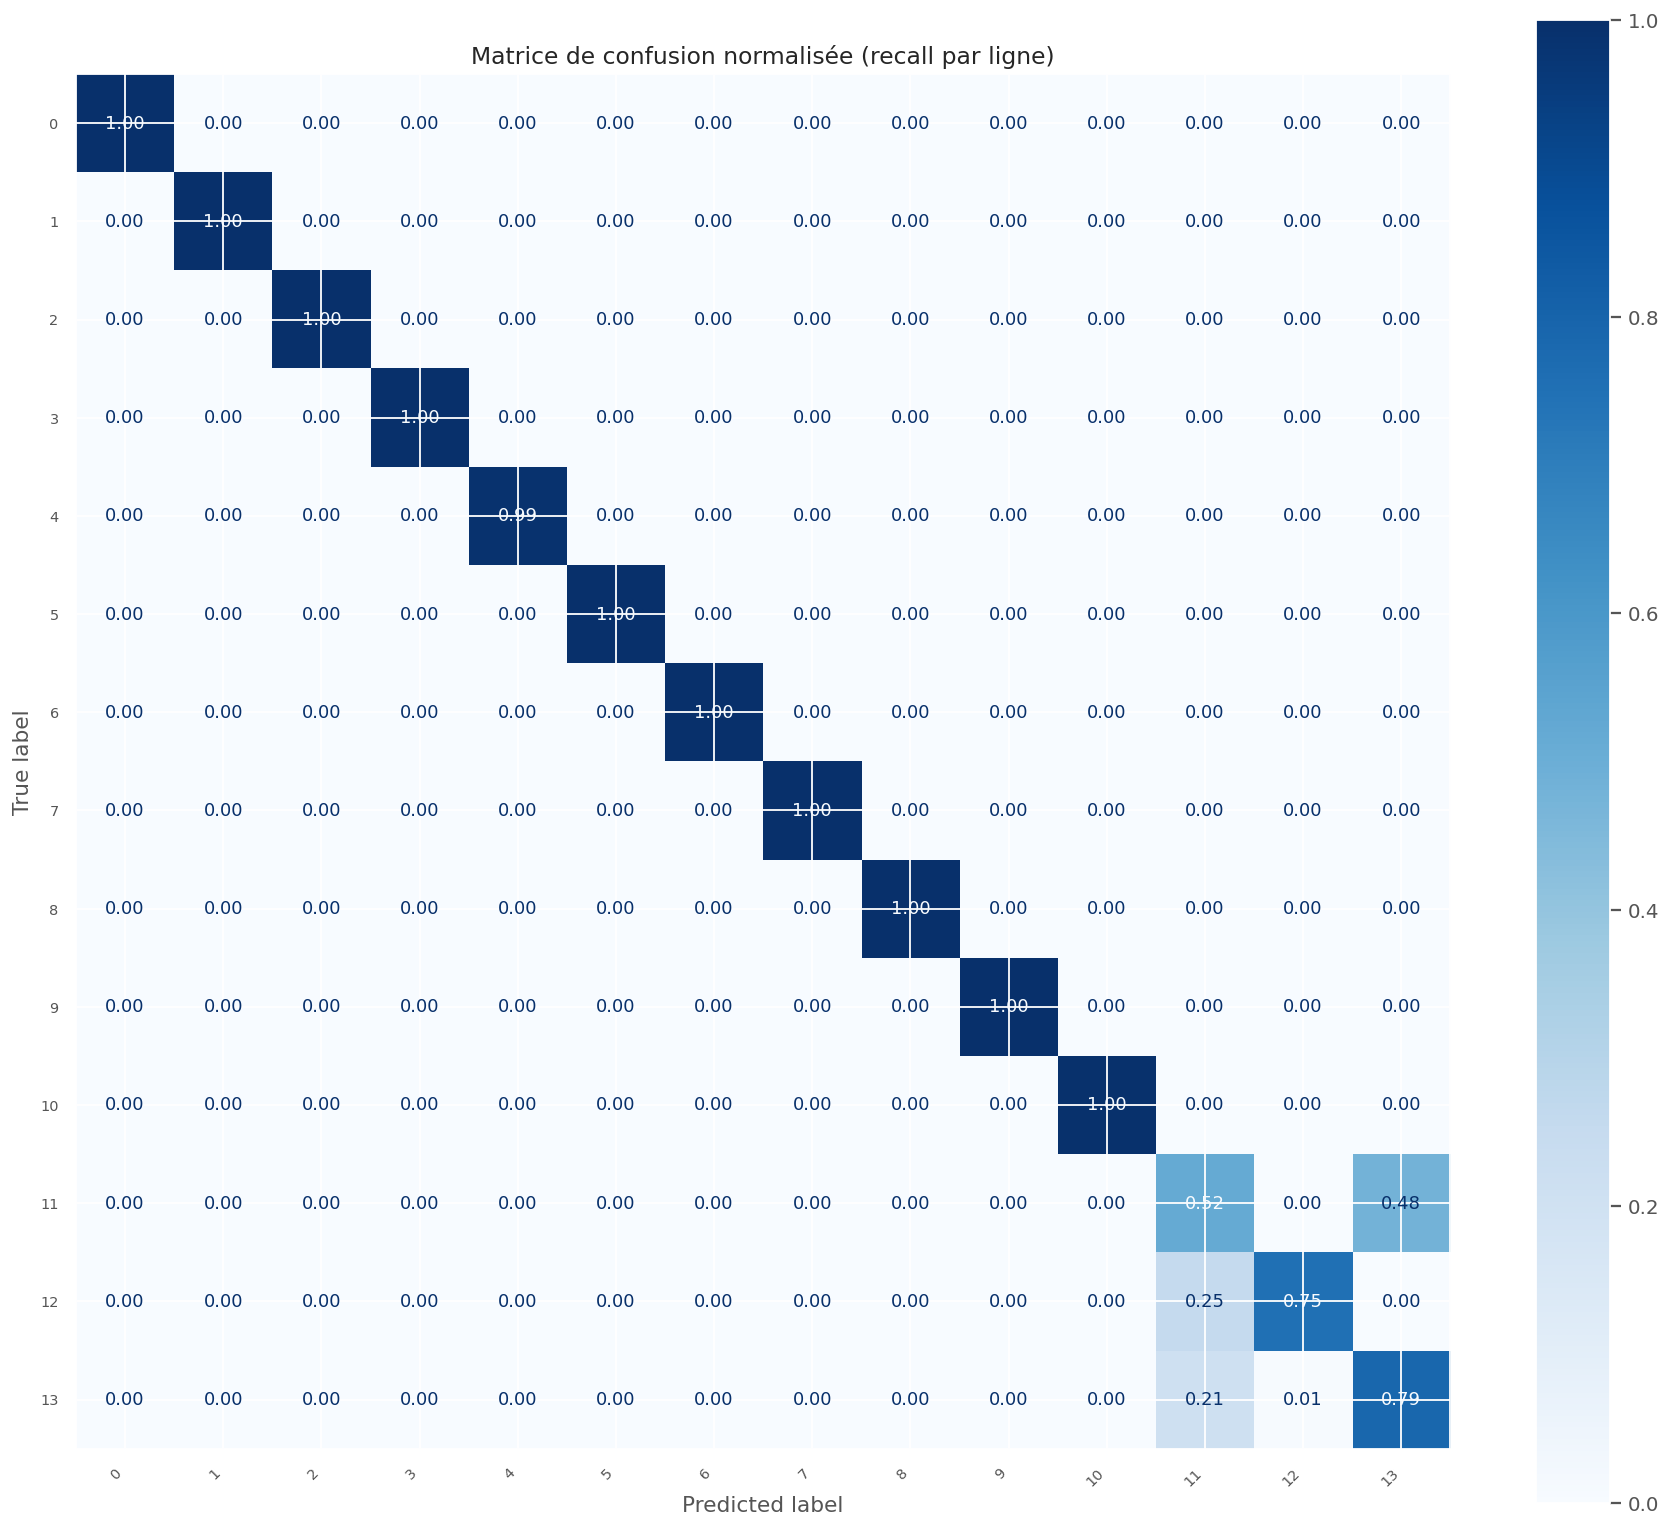

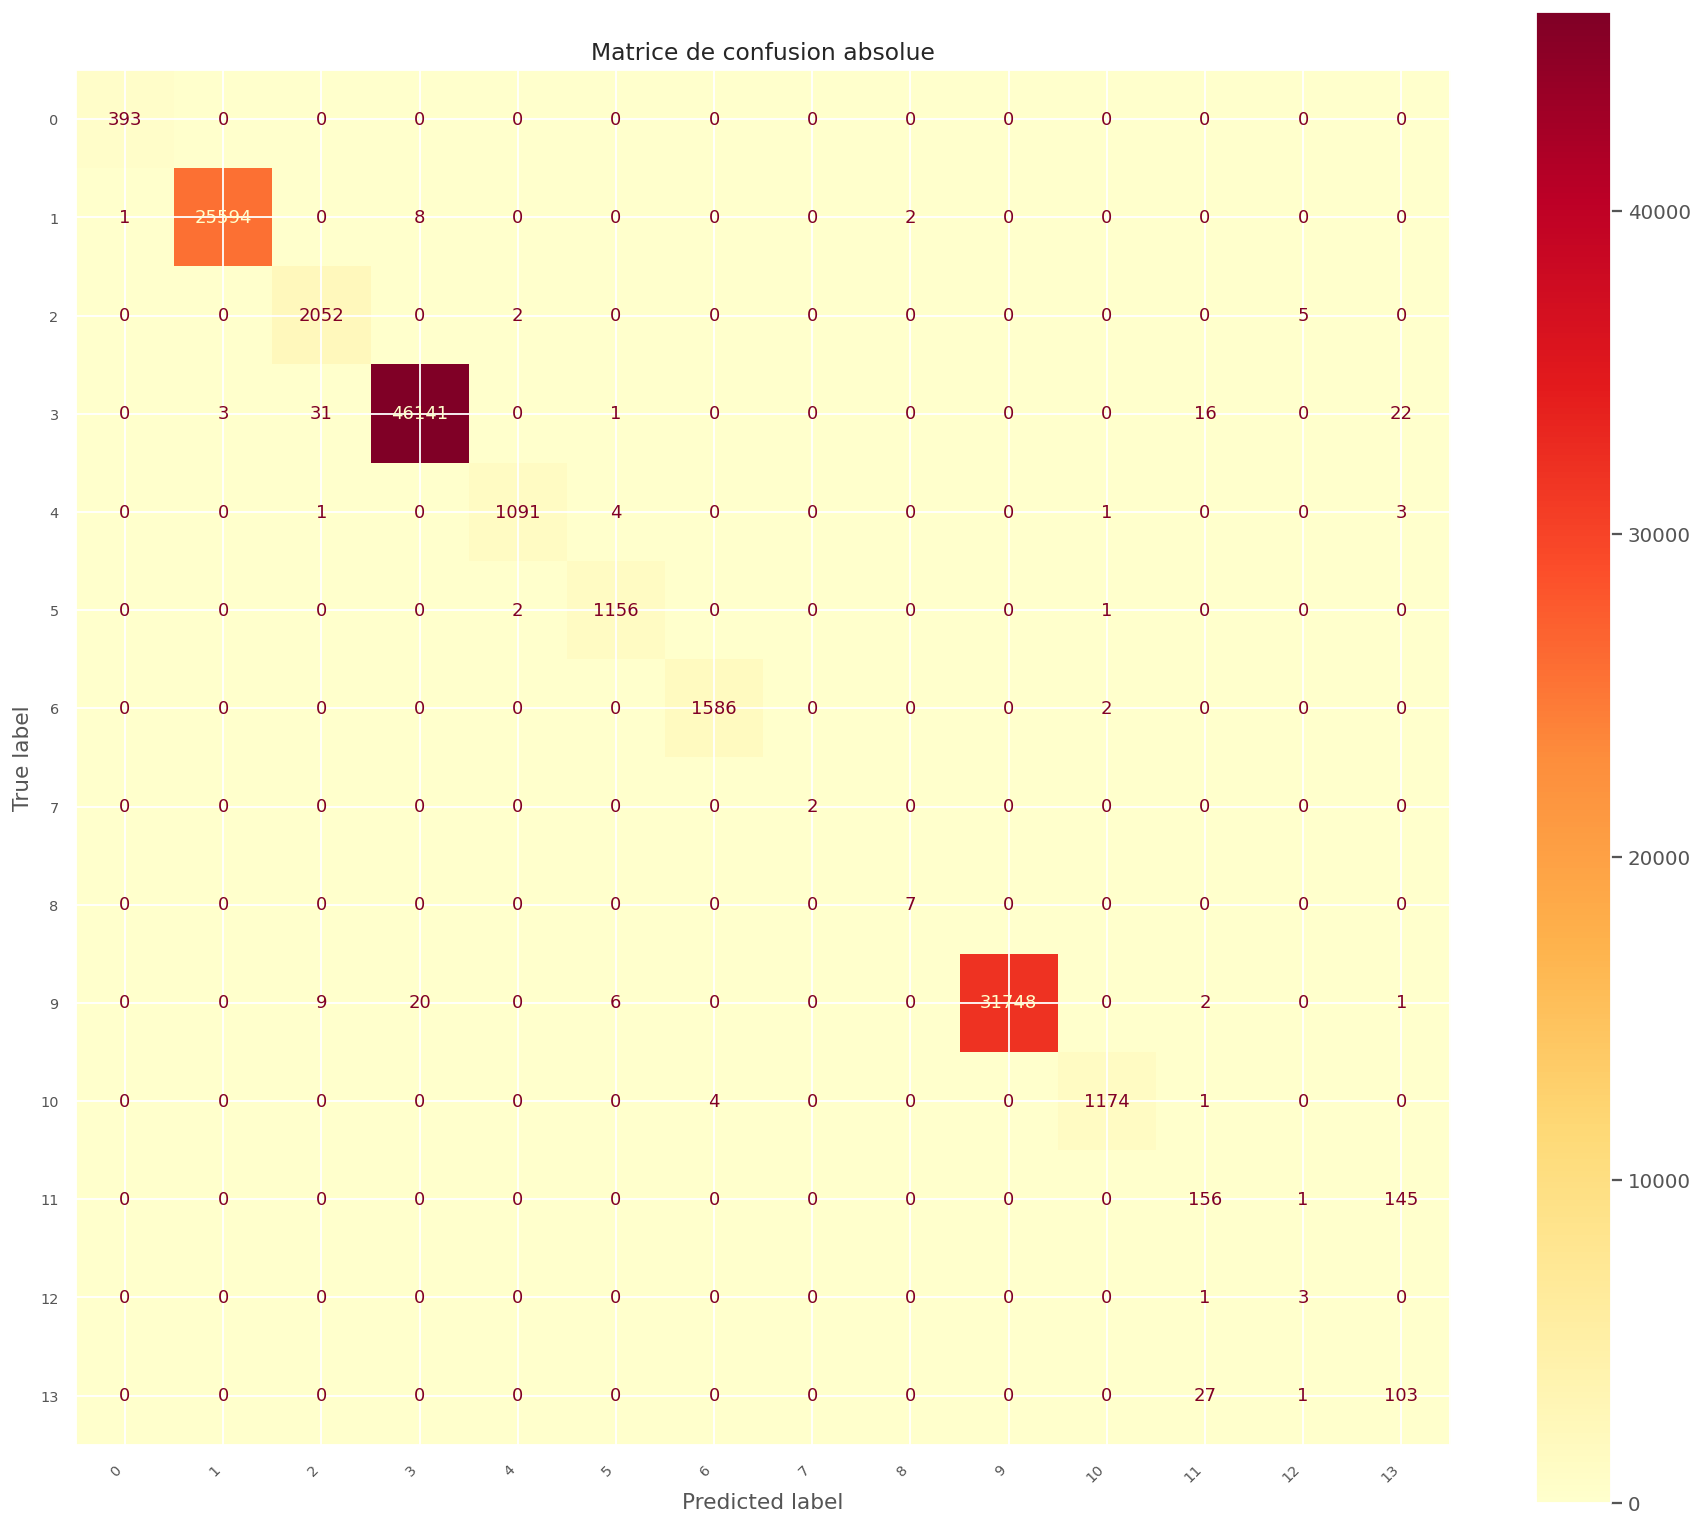

In [22]:
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels = CLASS_NAMES,
    ax             = ax,
    colorbar       = True,
    cmap           = "Blues",
    normalize      = "true",           # normalisation par ligne = recall par classe
    values_format  = ".2f",
)
ax.set_title("Matrice de confusion normalisée (recall par ligne)", fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

# ── Version absolue (complémentaire) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels = CLASS_NAMES,
    ax             = ax,
    colorbar       = True,
    cmap           = "YlOrRd",
    normalize      = None,
    values_format  = "d",
)
ax.set_title("Matrice de confusion absolue", fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_abs.png", bbox_inches="tight")
plt.show()

## §16 · Analyse par classe — identification des classes faibles

Cette section identifie les classes d'attaques où le modèle échoue.  
Un recall faible signifie que des attaques passent inaperçues — le risque le plus critique dans un IDS.

Performances par classe (triées par F1 croissant) :
 class  support  precision  recall     f1
    12        4     0.3000  0.7500 0.4286
    13      131     0.3759  0.7863 0.5086
    11      302     0.7685  0.5166 0.6178
     8        7     0.7778  1.0000 0.8750
     2     2059     0.9804  0.9966 0.9884
     5     1159     0.9906  0.9974 0.9940
     4     1100     0.9963  0.9918 0.9941
    10     1179     0.9966  0.9958 0.9962
     6     1588     0.9975  0.9987 0.9981
     0      393     0.9975  1.0000 0.9987
     3    46214     0.9994  0.9984 0.9989
     9    31786     1.0000  0.9988 0.9994
     1    25605     0.9999  0.9996 0.9997
     7        2     1.0000  1.0000 1.0000


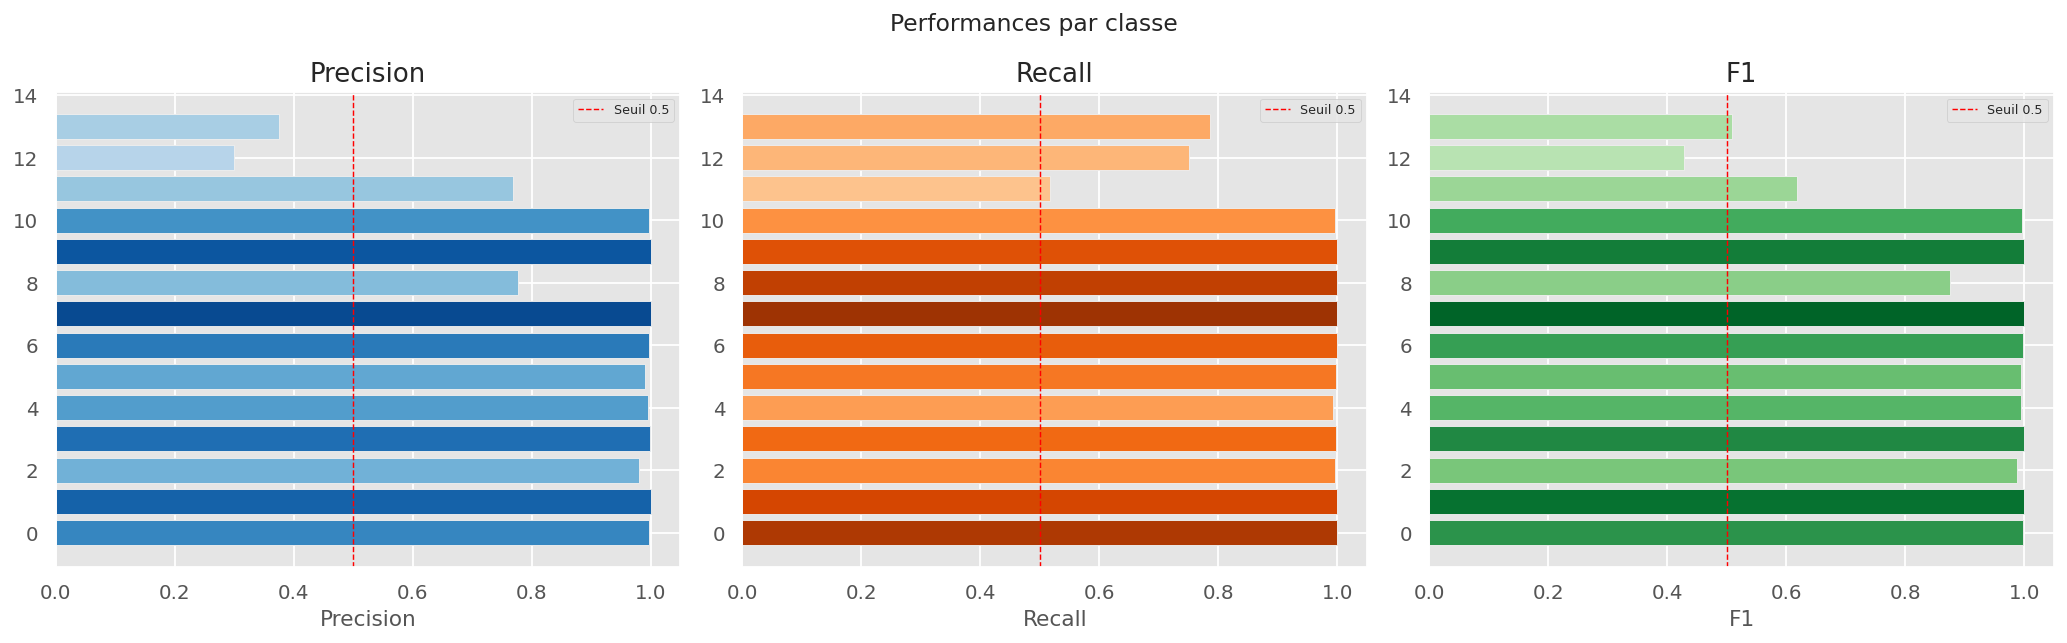


✓ Toutes les classes ont un recall ≥ 0.5


In [23]:
from sklearn.metrics import precision_recall_fscore_support

precision_arr, recall_arr, f1_arr, support_arr = precision_recall_fscore_support(
    y_test, y_pred, labels=list(range(N_CLASSES)), zero_division=0
)

per_class_df = pd.DataFrame({
    "class"     : CLASS_NAMES,
    "support"   : support_arr,
    "precision" : precision_arr,
    "recall"    : recall_arr,
    "f1"        : f1_arr,
}).sort_values("f1")

print("Performances par classe (triées par F1 croissant) :")
print(per_class_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_vis = [("precision", "Blues"), ("recall", "Oranges"), ("f1", "Greens")]
for ax, (metric, cmap) in zip(axes, metrics_vis):
    df_sorted = per_class_df.sort_values(metric)
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(df_sorted)))
    bars = ax.barh(df_sorted["class"], df_sorted[metric], color=colors)
    ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="Seuil 0.5")
    ax.set_xlim(0, 1.05)
    ax.set_title(metric.capitalize())
    ax.set_xlabel(metric.capitalize())
    ax.legend(fontsize=7)
plt.suptitle("Performances par classe", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_metrics.png", bbox_inches="tight")
plt.show()

# ── Alerte classes critiques ──────────────────────────────────────────────────
weak_classes = per_class_df[per_class_df["recall"] < 0.5]
if len(weak_classes) > 0:
    print(f"\n⚠ {len(weak_classes)} classe(s) avec recall < 0.5 (attaques non détectées) :")
    print(weak_classes[["class", "support", "recall", "f1"]].to_string(index=False))
else:
    print("\n✓ Toutes les classes ont un recall ≥ 0.5")

## §17 · Importance des features

### Limites de l'importance built-in
- **Weight** : biais vers les features continues à haute cardinalité
- **Gain** : plus fiable — reflète l'amélioration de l'objectif

Ces métriques sont globales et ne distinguent pas les contributions par classe.  
SHAP (§18) fournit une analyse plus fine par exemple et par classe.

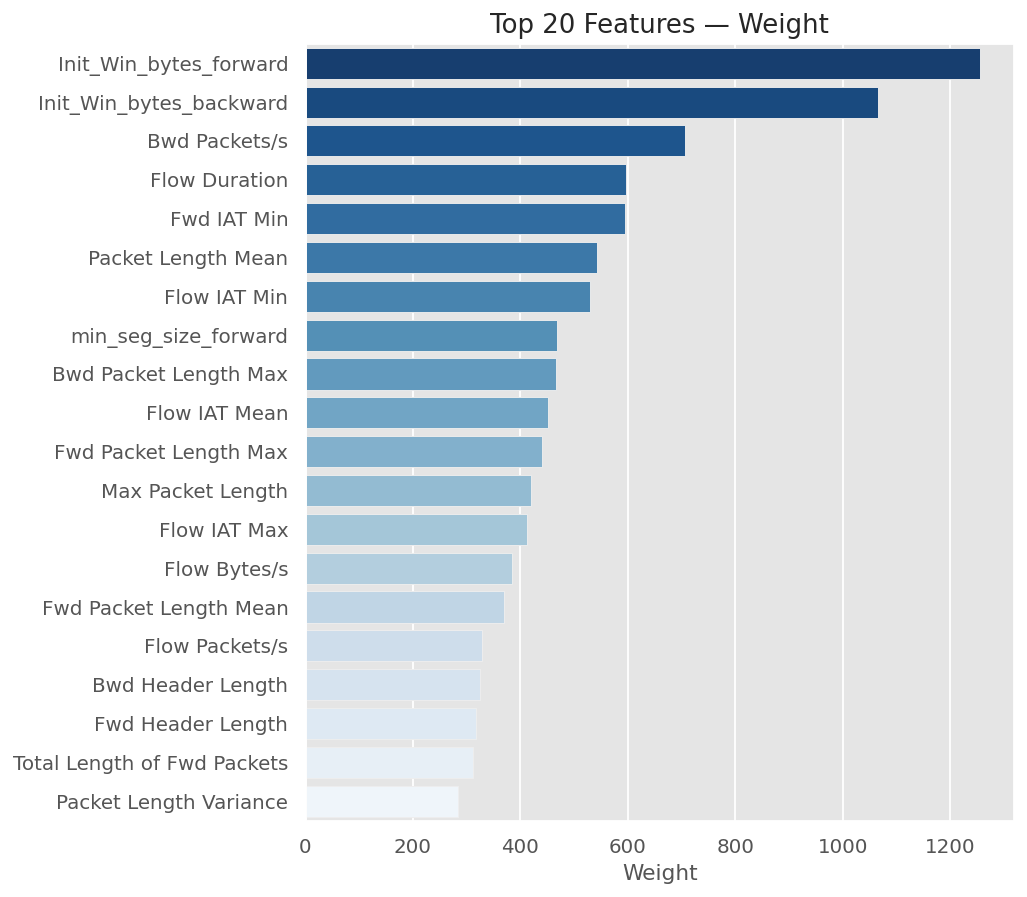

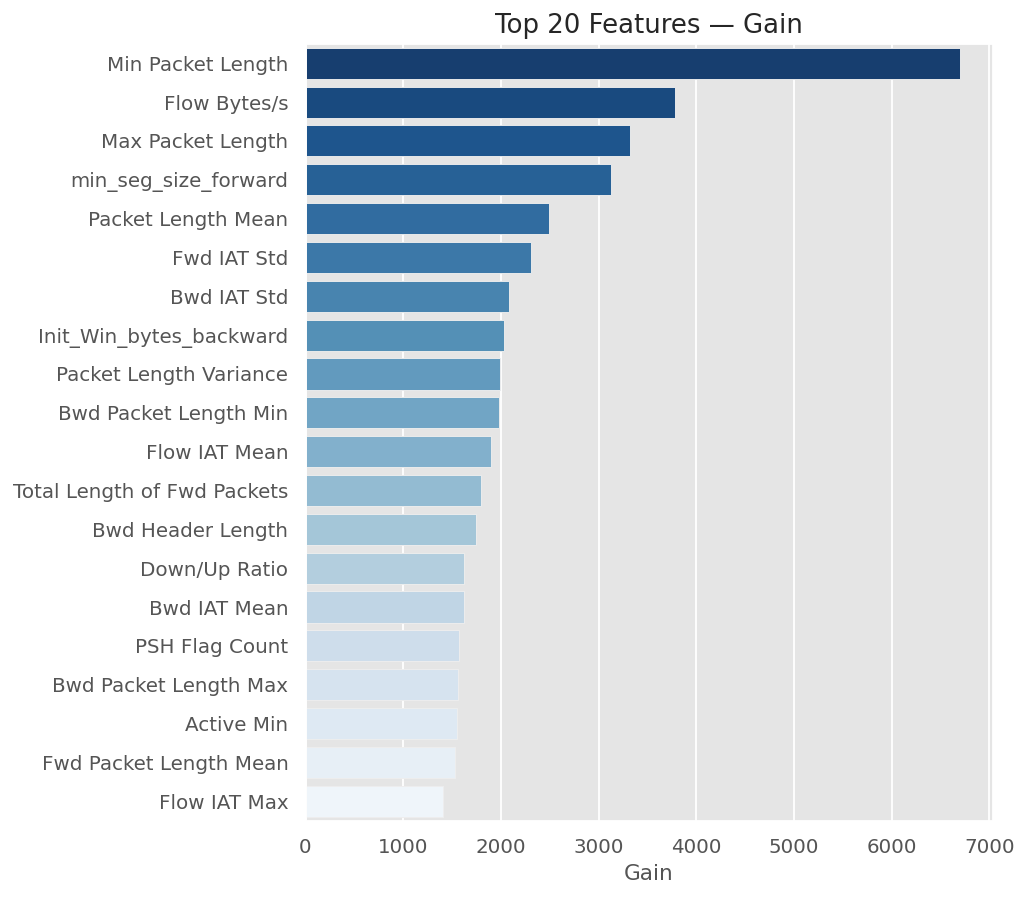

In [24]:
for imp_type in ["weight", "gain"]:
    scores = final_model.get_score(importance_type=imp_type)
    imp_df = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
    )
    imp_df.columns = ["feature", "importance"]

    fig, ax = plt.subplots(figsize=(8, max(4, len(imp_df) * 0.35)))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="Blues_r")
    ax.set_title(f"Top 20 Features — {imp_type.capitalize()}")
    ax.set_xlabel(imp_type.capitalize())
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"feature_importance_{imp_type}.png", bbox_inches="tight")
    plt.show()

## §18 · Explicabilité SHAP — multiclasse

En multiclasse, `TreeExplainer` retourne un tableau `shap_values` de forme  
`(n_samples, n_features, n_classes)` — une matrice de contributions par classe.

On analyse :
1. **Beeswarm global** — top features tous classes confondus
2. **Bar plot par classe** — quelles features pilotent chaque type d'attaque

> Sur des datasets volumineux, SHAP est calculé sur un sous-échantillon  
> de `SHAP_SAMPLE_SIZE` exemples pour limiter les temps de calcul.

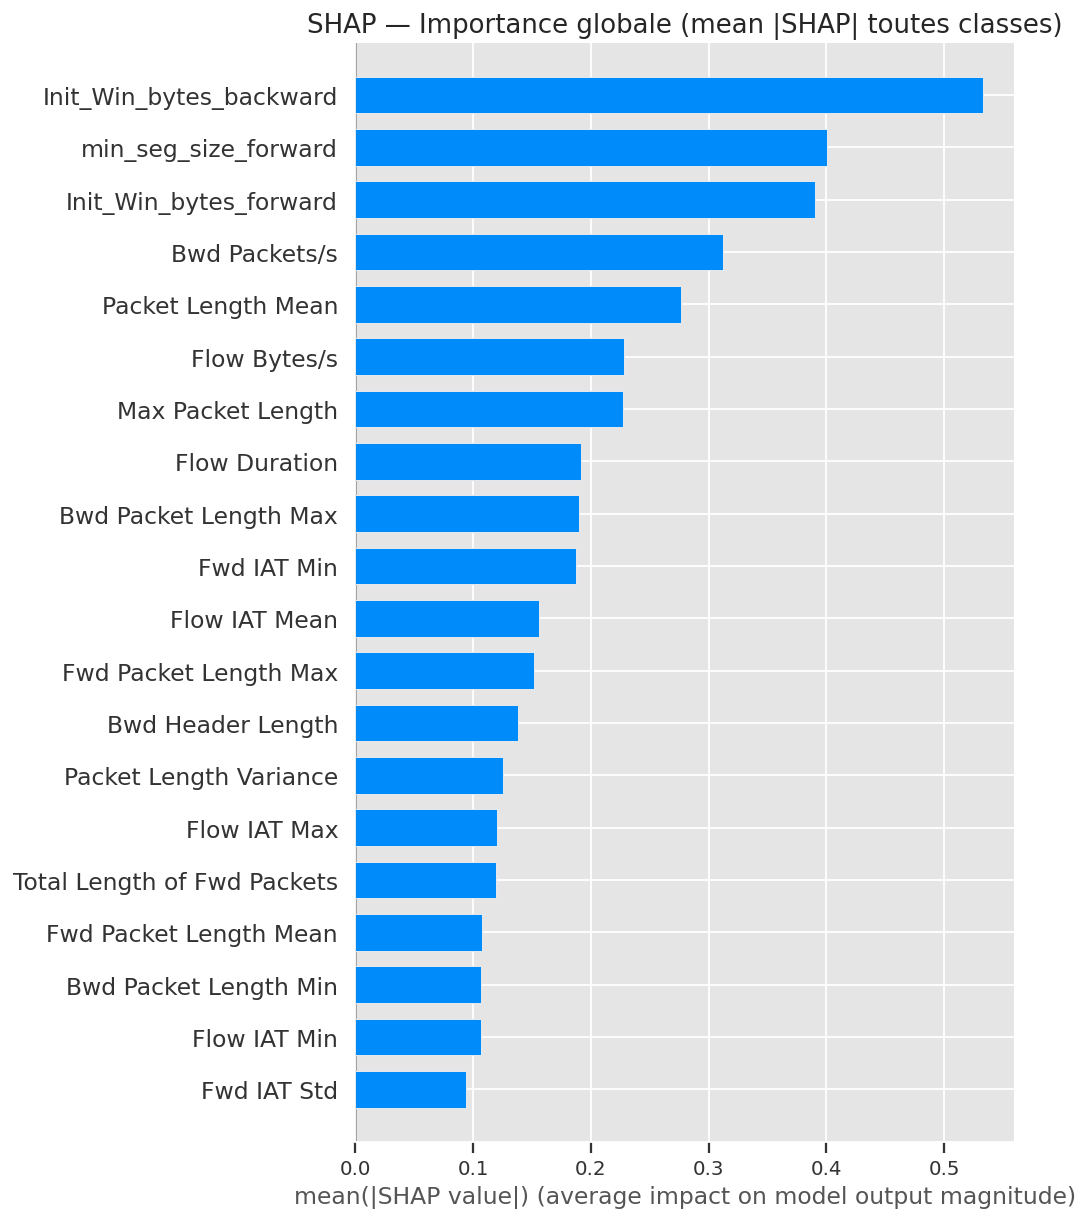

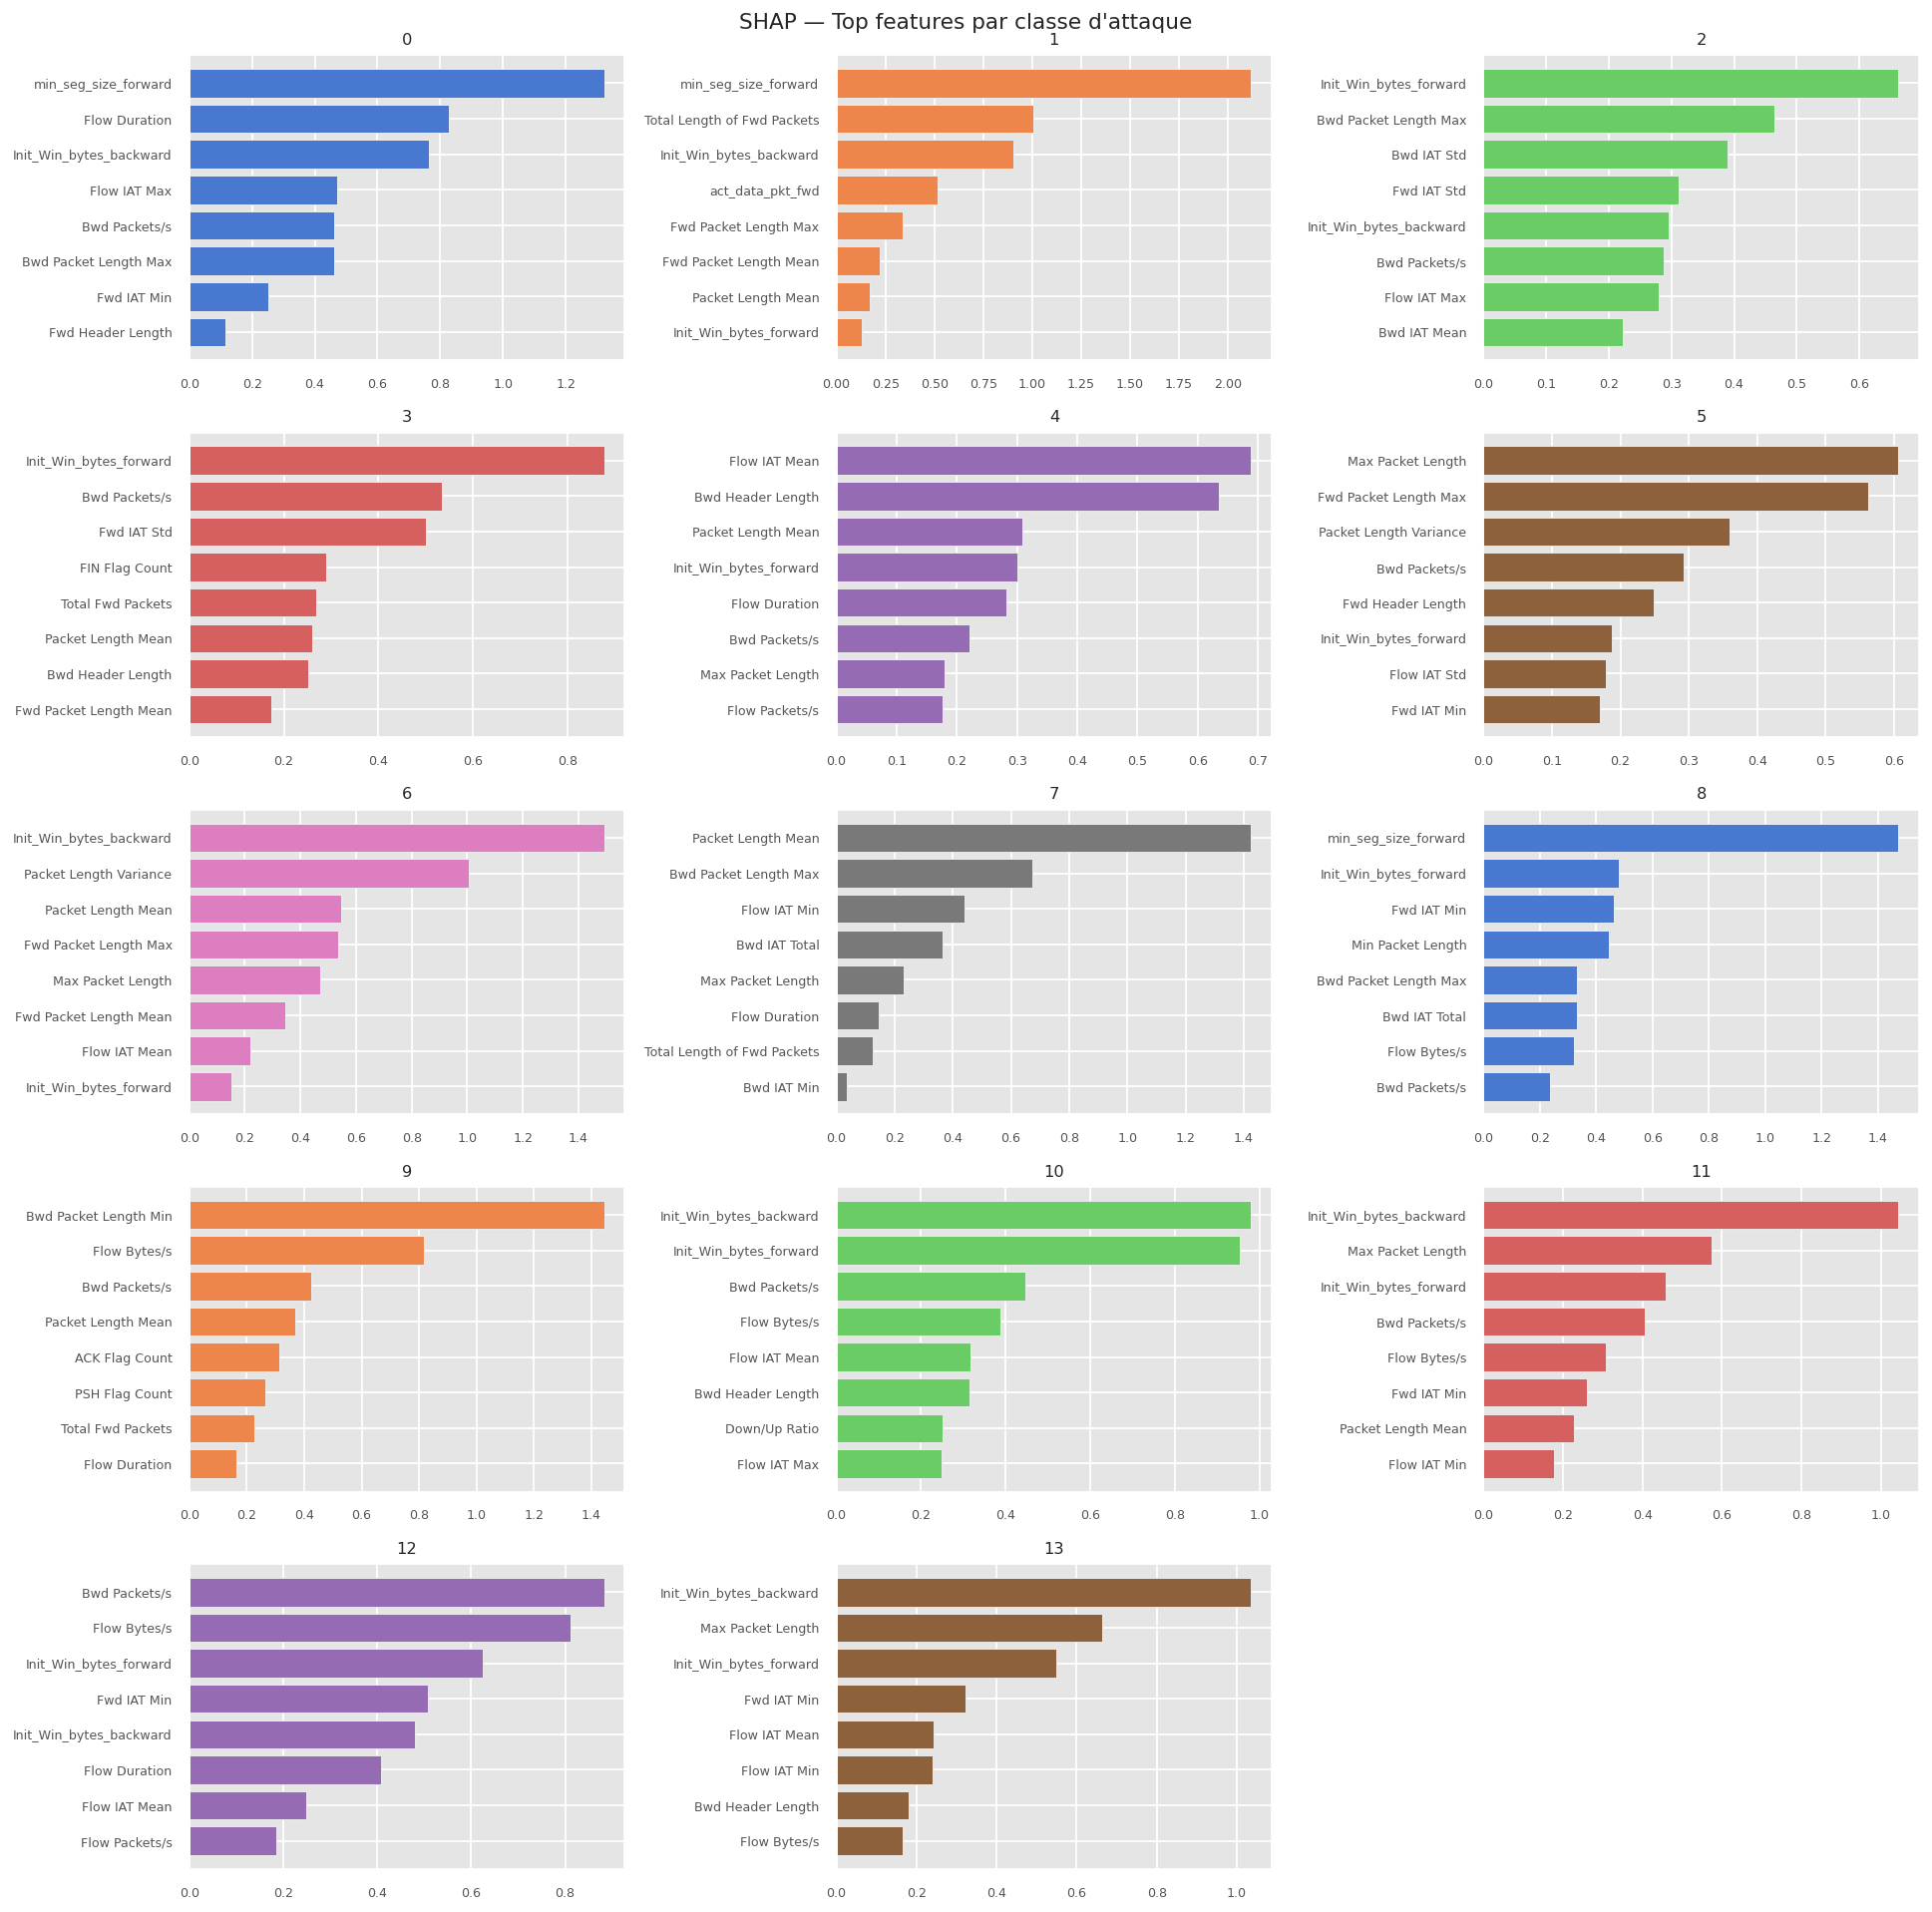

In [25]:
X_shap = X_test.sample(min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
y_shap = y_test.loc[X_shap.index]

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap.values)
# shap_values shape : (n_samples, n_features, N_CLASSES)

# ── 1. Summary plot global (mean abs sur toutes les classes) ──────────────────
shap_mean_abs = np.abs(shap_values).mean(axis=2)   # (n_samples, n_features)
plt.figure(figsize=(9, 8))
shap.summary_plot(
    shap_mean_abs, X_shap,
    feature_names = FEATURE_NAMES,
    max_display   = 20,
    plot_type     = "bar",
    show          = False,
)
plt.title("SHAP — Importance globale (mean |SHAP| toutes classes)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global.png", bbox_inches="tight")
plt.show()

# ── 2. Top features par classe (bar plot) ─────────────────────────────────────
n_cols = 3
n_rows = (N_CLASSES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for cls_idx in range(N_CLASSES):
    mean_imp = np.abs(shap_values[:, :, cls_idx]).mean(axis=0)
    top_n    = min(8, len(FEATURE_NAMES))
    top_idx  = np.argsort(mean_imp)[-top_n:][::-1]
    axes[cls_idx].barh(
        [FEATURE_NAMES[i] for i in top_idx],
        mean_imp[top_idx],
        color=sns.color_palette("muted")[cls_idx % 8]
    )
    axes[cls_idx].set_title(f"{CLASS_NAMES[cls_idx]}", fontsize=9)
    axes[cls_idx].invert_yaxis()
    axes[cls_idx].tick_params(labelsize=7)

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle("SHAP — Top features par classe d'attaque", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_per_class.png", bbox_inches="tight")
plt.show()

## §19 · Logging MLflow

In [26]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="xgboost_multiclass_final") as run:
    mlflow.log_params({
        **study.best_params,
        "n_boost_round"  : best_n_rounds,
        "n_optuna_trials": N_OPTUNA_TRIALS,
        "n_cv_splits"    : N_SPLITS,
        "objective"      : OBJECTIVE,
        "n_classes"      : N_CLASSES,
        "smote_applied"  : SMOTE_APPLIED,
        "train_rows"     : len(X_train_bal),
        "n_features"     : len(FEATURE_NAMES),
    })
    mlflow.log_metrics({
        **metrics,
        "cv_macro_f1_mean"    : float(cv_f1_macro.mean()),
        "cv_macro_f1_std"     : float(cv_f1_macro.std()),
        "cv_weighted_f1_mean" : float(cv_f1_weighted.mean()),
        "cv_bal_acc_mean"     : float(cv_bal_acc.mean()),
    })
    mlflow.xgboost.log_model(final_model, artifact_path="model")
    for img in sorted(OUTPUT_DIR.glob("*.png")):
        mlflow.log_artifact(str(img), artifact_path="plots")
    run_id = run.info.run_id

log.info("MLflow run_id: %s", run_id)

2026/06/15 05:42:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/15 05:42:08 INFO mlflow.store.db.utils: Updating database tables
2026/06/15 05:42:13 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_ids_multiclass' does not exist. Creating a new experiment.
2026/06/15 05:42:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## §20 · Sauvegarde des artefacts

In [28]:
metadata = {
    "task"          : "multiclass_classification",
    "classes"       : CLASS_NAMES,
    "n_classes"     : N_CLASSES,
    "feature_names" : FEATURE_NAMES,
    "n_features"    : len(FEATURE_NAMES),
    "n_boost_round" : best_n_rounds,
    "smote_applied" : SMOTE_APPLIED,
    "best_params"   : study.best_params,
    "mlflow_run_id" : run_id,
    "metrics" : {
        "test" : {k: round(float(v), 6) for k, v in metrics.items()},
        "cv"   : {
            "macro_f1"    : {"mean": round(float(cv_f1_macro.mean()), 6),
                             "std" : round(float(cv_f1_macro.std()),  6)},
            "weighted_f1" : {"mean": round(float(cv_f1_weighted.mean()), 6),
                             "std" : round(float(cv_f1_weighted.std()),  6)},
            "bal_acc"     : {"mean": round(float(cv_bal_acc.mean()), 6),
                             "std" : round(float(cv_bal_acc.std()),  6)},
        },
    },
}

def convert(o):
    if hasattr(o, "item"):
        return o.item()
    if isinstance(o, (np.ndarray, list)):
        return o.tolist()
    return str(o)

with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=convert)

print("✓ Artefacts sauvegardés dans :", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"   {p.name:<45} {p.stat().st_size/1024:>7.1f} KB")

✓ Artefacts sauvegardés dans : /content/drive/.shortcut-targets-by-id/14etjy9PavLV8MW-ReyUUXaRf4oXZ57Du/PFA_/outputs-XGboost-attacks
   baseline_learning_curves.png                     74.9 KB
   class_distribution.png                           46.6 KB
   confusion_matrix.png                             86.2 KB
   confusion_matrix_abs.png                         82.2 KB
   cv_learning_curve.png                            33.5 KB
   feature_importance_gain.png                      82.0 KB
   feature_importance_weight.png                    86.6 KB
   metadata.json                                     2.0 KB
   optuna_history.png                               39.2 KB
   optuna_param_importance.png                      32.7 KB
   optuna_study_mc.db                             1004.0 KB
   per_class_metrics.png                            45.9 KB
   shap_global.png                                 119.6 KB
   shap_per_class.png                              238.7 KB
   xgboost_multiclass_final

## §21 · Fonction d'inférence multiclasse

Retourne la classe prédite, son nom, la probabilité de confiance,  
et les probabilités pour toutes les classes (utile pour les classes proches).

In [29]:
def predict(X: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    """
    Inférence multiclasse sur de nouvelles données pré-traitées.

    Parameters
    ----------
    X     : DataFrame avec les mêmes colonnes que X_train
    top_k : nombre de classes alternatives retournées (probabilités)

    Returns
    -------
    DataFrame : prediction | label | confidence | top_k_classes
    """
    dm         = xgb.DMatrix(X[FEATURE_NAMES], feature_names=FEATURE_NAMES)
    prob_mat   = final_model.predict(dm).reshape(-1, N_CLASSES)   # (n, N_CLASSES)
    pred_idx   = np.argmax(prob_mat, axis=1)
    confidence = prob_mat[np.arange(len(pred_idx)), pred_idx]

    # Top-k classes avec leurs probabilités
    top_k_list = []
    for row in prob_mat:
        top_idx = np.argsort(row)[-top_k:][::-1]
        top_k_list.append(
            {CLASS_NAMES[i]: round(float(row[i]), 4) for i in top_idx}
        )

    return pd.DataFrame({
        "prediction" : pred_idx,
        "label"      : [CLASS_NAMES[i] for i in pred_idx],
        "confidence" : confidence.round(4),
        "top_k"      : top_k_list,
    })


# ── Test rapide ───────────────────────────────────────────────────────────────
sample_result = predict(X_test.head(8))
sample_result["true_label"] = [CLASS_NAMES[v] for v in y_test.head(8).values]
sample_result["correct"]    = sample_result["label"] == sample_result["true_label"]
display(sample_result[["label", "true_label", "correct", "confidence"]])

,label,true_label,correct,confidence
0,3,3,True,0.9191
1,1,1,True,0.9979
2,5,5,True,0.9865
3,1,1,True,0.9984
4,5,4,False,0.9865
5,9,9,True,0.9989
6,3,3,True,0.9989
7,9,9,True,0.9989


## §22 · Résumé final et recommandations

In [30]:
print("\n" + "═" * 60)
print("  RÉSUMÉ DU PIPELINE MULTICLASSE")
print("═" * 60)
print(f"  Classes               : {N_CLASSES}")
print(f"  Train (après bal.)    : {len(X_train_bal):,} lignes")
print(f"  Test                  : {len(X_test):,} lignes")
print(f"  Features              : {len(FEATURE_NAMES)}")
print(f"  SMOTE appliqué        : {SMOTE_APPLIED}")
print(f"  Arbres (final)        : {best_n_rounds}")
print(f"  Trials Optuna         : {N_OPTUNA_TRIALS}")
print()
print(f"  Validation croisée {N_SPLITS}-fold :")
print(f"    macro-F1     : {cv_f1_macro.mean():.4f} ± {cv_f1_macro.std():.4f}")
print(f"    weighted-F1  : {cv_f1_weighted.mean():.4f} ± {cv_f1_weighted.std():.4f}")
print(f"    bal-accuracy : {cv_bal_acc.mean():.4f} ± {cv_bal_acc.std():.4f}")
print()
print("  Métriques test set :")
for k, v in metrics.items():
    marker = "  ← primaire" if k == "macro_f1" else ("  ← secondaire" if k == "accuracy" else "")
    print(f"    {k:<28} {v:.4f}{marker}")
print("═" * 60)
print()
print("Recommandations pour améliorations futures :")
print("  1. SHAP per-class waterfall pour les classes à faible recall")
print("  2. Temporal split pour évaluation réaliste (éviter chevauchement)")
print("  3. Calibration des probabilités (Platt scaling ou isotonic)")
print("  4. Ensemble XGBoost + LightGBM pour comparaison")
print("  5. Feature selection basée sur SHAP (supprimer features à SHAP ≈ 0)")


════════════════════════════════════════════════════════════
  RÉSUMÉ DU PIPELINE MULTICLASSE
════════════════════════════════════════════════════════════
  Classes               : 14
  Train (après bal.)    : 446,116 lignes
  Test                  : 111,529 lignes
  Features              : 42
  SMOTE appliqué        : False
  Arbres (final)        : 185
  Trials Optuna         : 60

  Validation croisée 5-fold :
    macro-F1     : 0.9262 ± 0.0165
    weighted-F1  : 0.9977 ± 0.0003
    bal-accuracy : 0.9573 ± 0.0080

  Métriques test set :
    macro_f1                     0.8855  ← primaire
    weighted_f1                  0.9973
    balanced_accuracy            0.9307
    accuracy                     0.9971  ← secondaire
════════════════════════════════════════════════════════════

Recommandations pour améliorations futures :
  1. SHAP per-class waterfall pour les classes à faible recall
  2. Temporal split pour évaluation réaliste (éviter chevauchement)
  3. Calibration des probabil